# 🚀 Lab 16: Handling Missing Values and Outliers

### 📘 Lab Overview
In this lab, you will learn how to improve data quality by identifying and handling two very common real-world data problems: **missing values** and **outliers**. These problems can strongly affect analysis results, statistical summaries, and machine learning model performance if they are not handled carefully.

You will work with a realistic customer-style dataset that contains missing values and outliers. You will detect missing values, apply mean and median imputation, identify outliers using IQR and z-score methods, cap extreme values, and build a complete reusable cleaning pipeline.

### 🎯 Objectives
By the end of this lab, you will be able to:
* Detect missing values using pandas.
* Apply mean and median imputation techniques.
* Identify outliers using **IQR (Interquartile Range)** and **Z-score** methods.
* Handle outliers by capping extreme values.
* Build a complete data cleaning workflow.

### 🧰 Prerequisites
* Basic Python (loops, functions).
* Familiarity with the `pandas` library.
* Basic statistics (mean, median, standard deviation).

---

## ⚙️ Environment Setup

### 🧒 ELI10: What are we doing?
Before we start fixing data, we need to gather our tools. Think of this like setting up a workbench with a ruler (pandas), a calculator (numpy), and some drawing paper (matplotlib/seaborn) so we can see what the data looks like.

In [1]:
# Step 1: Install necessary libraries (usually pre-installed in Colab)
%pip install pandas numpy matplotlib seaborn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Ignore warnings for cleaner output
warnings.filterwarnings('ignore')

# Set display options for better output formatting
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
Pandas version: 2.2.2
NumPy version: 2.0.2


## 🧪 Creating the Sample Dataset

### 🧒 ELI10: What are we doing?
Real-world data is messy. Since we don't have a messy file yet, we are going to 'break' some perfect data on purpose by deleting numbers and adding some crazy high values so we can practice fixing them.

In [2]:
# Set random seed so the 'random' numbers are the same every time we run this
np.random.seed(42)

# Create 1000 rows of customer data
n_samples = 1000

# Generate base data using normal distributions
data = {
    'customer_id': range(1, n_samples + 1),
    'age': np.random.normal(35, 12, n_samples),
    'income': np.random.normal(50000, 15000, n_samples),
    'purchase_amount': np.random.normal(200, 50, n_samples),
    'satisfaction_score': np.random.normal(7, 1.5, n_samples),
    'years_customer': np.random.normal(3, 2, n_samples)
}

df = pd.DataFrame(data)

# 1. Introduce Missing Values (NaN - Not a Number)
# We pick random spots to delete data to simulate real-world 'missing' entries
missing_indices_age = np.random.choice(df.index, size=50, replace=False)
missing_indices_income = np.random.choice(df.index, size=30, replace=False)
missing_indices_satisfaction = np.random.choice(df.index, size=40, replace=False)

df.loc[missing_indices_age, 'age'] = np.nan
df.loc[missing_indices_income, 'income'] = np.nan
df.loc[missing_indices_satisfaction, 'satisfaction_score'] = np.nan

# 2. Introduce Outliers (Extreme Values)
# We make some people have 3x normal income and set some ages to 90
outlier_indices = np.random.choice(df.index, size=20, replace=False)
df.loc[outlier_indices, 'income'] = df.loc[outlier_indices, 'income'] * 3
df.loc[outlier_indices[:10], 'age'] = 90

# Ensure we don't have negative values (age can't be -5!)
df['age'] = np.abs(df['age'])
df['income'] = np.abs(df['income'])
df['purchase_amount'] = np.abs(df['purchase_amount'])
df['years_customer'] = np.abs(df['years_customer'])

print("Dataset created successfully!")
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows with potential missing values:")
display(df.head())

Dataset created successfully!
Dataset shape: (1000, 6)

First 5 rows with potential missing values:


,customer_id,age,income,purchase_amount,satisfaction_score,years_customer
0,1,40.960570,70990.331549,166.241086,4.138289,1.273013
1,2,NaN,63869.505244,192.774066,NaN,2.937593
2,3,42.772262,50894.455549,160.379004,6.379592,3.036034
3,4,90.000000,120887.845003,184.601924,9.831531,3.945261
4,5,32.190160,60473.349704,105.319267,7.834830,0.266283


## 🔍 Detecting Missing Values

### 🧒 ELI10: What are we doing?
Before fixing holes in a bucket, you have to find where they are. We will use code to count exactly how many empty spots exist in each column.

=== Missing Values Detection ===
Summary Table:


,Missing_Count,Missing_Percentage
customer_id,0,0.0
age,50,5.0
income,30,3.0
purchase_amount,0,0.0
satisfaction_score,40,4.0
years_customer,0,0.0


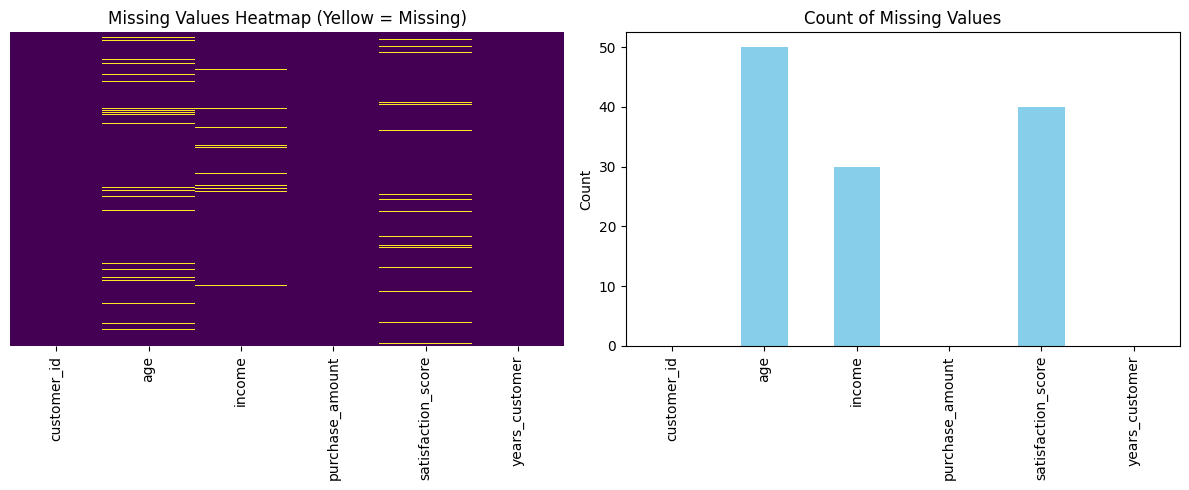

In [3]:
print("=== Missing Values Detection ===")

# Count nulls per column
missing_counts = df.isnull().sum()

# Calculate percentages for context
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Missing_Percentage': missing_percentage
})

print("Summary Table:")
display(missing_info)

# Visualize with a Heatmap
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap (Yellow = Missing)')

# Visualize with a Bar Chart
plt.subplot(1, 2, 2)
missing_counts.plot(kind='bar', color='skyblue')
plt.title('Count of Missing Values')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

## 🩹 Imputing Missing Values

### 🧒 ELI10: What are we doing?
'Imputation' is a fancy word for filling in the blanks.
* **Mean (Average):** Fill with the average of everyone. Good for normal data.
* **Median (Middle):** Fill with the middle value. Better if there are crazy high/low numbers (outliers) that would mess up the average.

=== Imputation Process ===
age: Imputed Mean=35.94, Median=35.57
income: Imputed Mean=53048.73, Median=51034.31
satisfaction_score: Imputed Mean=6.99, Median=7.02


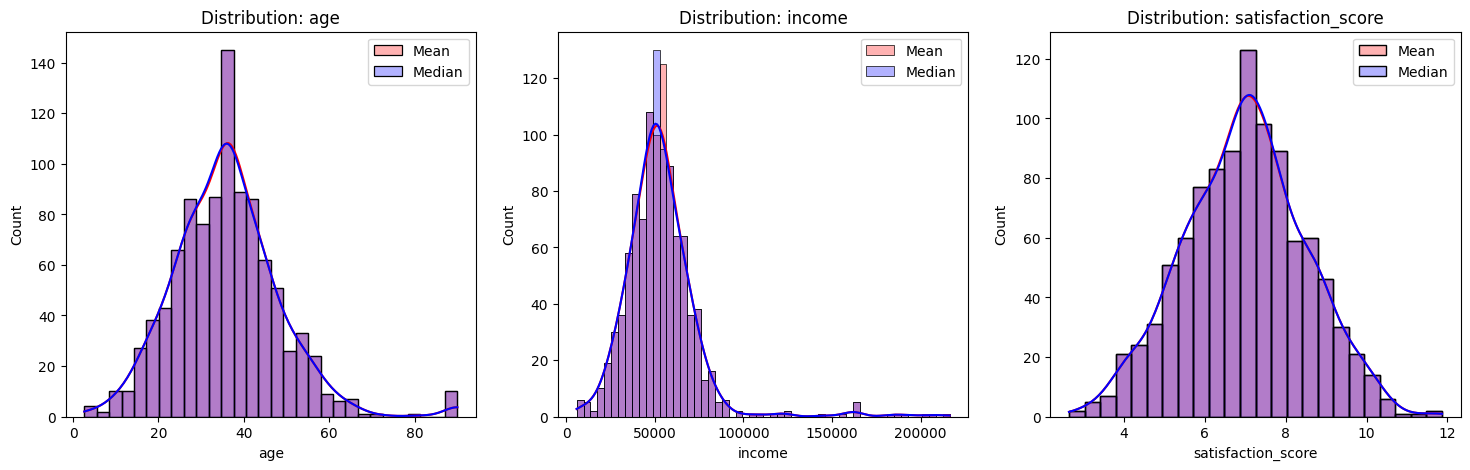

In [4]:
# Create copies for different methods
df_mean_imputed = df.copy()
df_median_imputed = df.copy()

# Identify columns to fix
numerical_cols = ['age', 'income', 'satisfaction_score']

print("=== Imputation Process ===")
for col in numerical_cols:
    # Mean Imputation
    m_val = df[col].mean()
    df_mean_imputed[col] = df_mean_imputed[col].fillna(m_val)

    # Median Imputation
    med_val = df[col].median()
    df_median_imputed[col] = df_median_imputed[col].fillna(med_val)

    print(f"{col}: Imputed Mean={m_val:.2f}, Median={med_val:.2f}")

# Comparison Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(numerical_cols):
    sns.histplot(df_mean_imputed[col], color="red", label="Mean", kde=True, ax=axes[i], alpha=0.3)
    sns.histplot(df_median_imputed[col], color="blue", label="Median", kde=True, ax=axes[i], alpha=0.3)
    axes[i].set_title(f'Distribution: {col}')
    axes[i].legend()
plt.show()

## 📦 Detecting Outliers

### 🧒 ELI10: What are we doing?
Imagine a classroom of 10-year-olds where one student is a 7-foot-tall basketball player. That student is an 'outlier'. We use **Box Plots** to see them visually and **IQR** or **Z-scores** to find them mathematically.

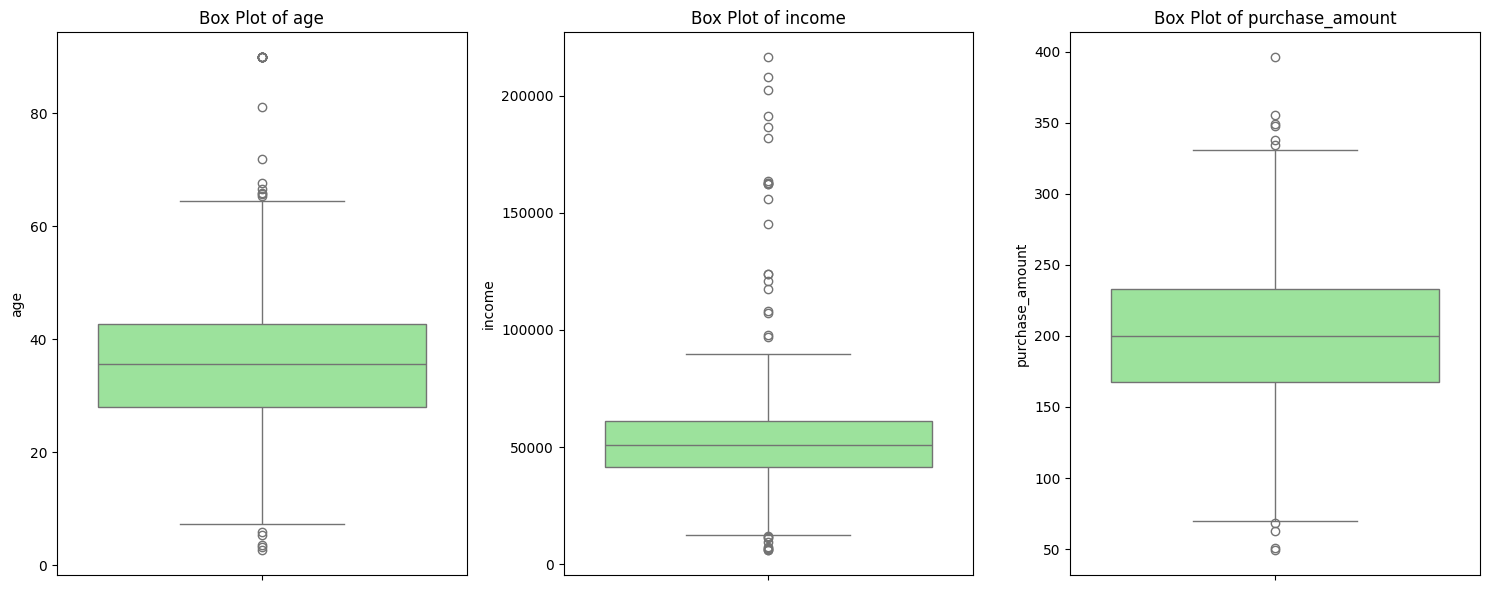


--- IQR Detection Summary ---
age: Found 22 outliers. Bounds: [6.06, 64.77]
income: Found 30 outliers. Bounds: [12168.81, 90544.47]


In [5]:
# We use the median imputed data as our base now
df_clean = df_median_imputed.copy()

# Visual Detection with Boxplots
plt.figure(figsize=(15, 6))
for i, col in enumerate(['age', 'income', 'purchase_amount']):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df_clean[col], color='lightgreen')
    plt.title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()

# Mathematical Detection (IQR Method)
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return outliers, lower, upper

print("\n--- IQR Detection Summary ---")
for col in ['age', 'income']:
    out, low, up = detect_outliers_iqr(df_clean, col)
    print(f"{col}: Found {len(out)} outliers. Bounds: [{low:.2f}, {up:.2f}]")

## ✂️ Handling Outliers (Capping)

### 🧒 ELI10: What are we doing?
Sometimes we don't want to delete an outlier. Instead, we 'cap' it. If someone's income is $1,000,000 and the limit is $200,000, we just change their number to $200,000. It keeps the data point but stops it from breaking our math.

In [6]:
def cap_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Use .clip to force values into the bounds
    return data[column].clip(lower=lower_bound, upper=upper_bound)

df_iqr_capped = df_clean.copy()
for col in ['age', 'income']:
    df_iqr_capped[col] = cap_outliers_iqr(df_iqr_capped, col)

print("Outliers Capped using IQR method.")
# Verify by checking max values before and after
print(f"Original Max Income: {df_clean['income'].max():.2f}")
print(f"Capped Max Income: {df_iqr_capped['income'].max():.2f}")

Outliers Capped using IQR method.
Original Max Income: 216444.32
Capped Max Income: 90544.47


## 🔗 Building a Cleaning Pipeline

### 🧒 ELI10: What are we doing?
Instead of doing these steps one by one every time, we can build a 'Robot Function' (Pipeline). We put raw data in, and it automatically handles missing values and outliers for us.

In [7]:
def comprehensive_data_cleaning(data, missing_strategy='median'):
    """
    A one-stop shop for cleaning the dataset.
    """
    cleaned_data = data.copy()
    numerical_cols = cleaned_data.select_dtypes(include=[np.number]).columns.drop('customer_id')

    # 1. Handle Missing Values
    for col in numerical_cols:
        fill_val = cleaned_data[col].median() if missing_strategy == 'median' else cleaned_data[col].mean()
        cleaned_data[col] = cleaned_data[col].fillna(fill_val)

    # 2. Handle Outliers (IQR Capping)
    for col in numerical_cols:
        Q1 = cleaned_data[col].quantile(0.25)
        Q3 = cleaned_data[col].quantile(0.75)
        IQR = Q3 - Q1
        cleaned_data[col] = cleaned_data[col].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)

    return cleaned_data

# Run the pipeline
df_final_cleaned = comprehensive_data_cleaning(df)
print("Pipeline executed. Dataset is now clean!")
display(df_final_cleaned.describe())

Pipeline executed. Dataset is now clean!


,customer_id,age,income,purchase_amount,satisfaction_score,years_customer
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,35.650359,51724.362101,200.205258,6.985006,3.055682
std,288.819436,11.598319,15569.793704,48.622321,1.497708,1.722475
min,1.000000,6.064521,12168.806413,69.431400,2.937880,0.000444
25%,250.750000,28.077262,41559.681206,167.600019,5.930746,1.722785
50%,500.500000,35.566276,51034.307552,199.987462,7.015285,2.980867
75%,750.250000,42.752423,61153.597735,233.045766,7.925991,4.278246
max,1000.000000,64.765165,90544.472528,331.214385,10.918857,8.111438


## ✅ Verification & Conclusion

### 🛠 Troubleshooting
* **NaNs after cleaning?** Ensure you didn't skip the imputation step before running Z-score math.
* **Too much data lost?** Use capping (clipping) instead of dropping rows (`dropna`).

### 📚 Key Takeaways
1. **Missing Data:** Always visualize first. Use median if the data is skewed.
2. **Outliers:** IQR is robust; Z-score is great for normally distributed data.
3. **Capping:** Keeps your sample size the same while removing extreme noise.

**The dataset has been exported as `cleaned_customer_data.csv`.**

In [8]:
# Export for use in other projects
df_final_cleaned.to_csv('cleaned_customer_data.csv', index=False)
print("File saved successfully.")

File saved successfully.
